In [1]:
# Celda 1 — Instalar dependencias y montar Drive
!pip install wandb -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.neural_network import MLPClassifier
from google.colab import drive
import pickle
import warnings
import wandb
from google.colab import userdata

wandb.login(key=userdata.get('WANDB_API_KEY'))
warnings.filterwarnings("ignore", category=FutureWarning)

np.random.seed(42)

drive.mount("/content/drive")
DRIVE_PATH = "/content/drive/MyDrive/ProyectoHIGGS/"

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
sns.set_style("whitegrid")
print("Setup completado.")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: diego-munozc (diego-munozc-universidad-de-antioquia) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Mounted at /content/drive
Setup completado.


In [2]:
# Celda 2 — Cargar splits desde Drive
X_train = np.load(DRIVE_PATH + "X_train.npy")
X_val   = np.load(DRIVE_PATH + "X_val.npy")
X_test  = np.load(DRIVE_PATH + "X_test.npy")
y_train = np.load(DRIVE_PATH + "y_train.npy")
y_val   = np.load(DRIVE_PATH + "y_val.npy")
y_test  = np.load(DRIVE_PATH + "y_test.npy")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (350000, 28), Val: (75000, 28), Test: (75000, 28)


In [3]:
# Celda 3 — Función de evaluación (5-Fold CV, scaler por fold)
def evaluar_modelo_cv(model, X_train, y_train, X_val, y_val, X_test, y_test,
                      nombre, k=5):
    kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    auc_folds, f1_folds, acc_folds, prec_folds, rec_folds = [], [], [], [], []

    for tr_idx, vl_idx in kf.split(X_train, y_train):
        scaler_cv = StandardScaler()
        X_tr_fold = scaler_cv.fit_transform(X_train[tr_idx])
        X_vl_fold = scaler_cv.transform(X_train[vl_idx])
        model.fit(X_tr_fold, y_train[tr_idx])
        y_prob = model.predict_proba(X_vl_fold)[:, 1]
        y_pred = model.predict(X_vl_fold)
        auc_folds.append(roc_auc_score(y_train[vl_idx], y_prob))
        f1_folds.append(f1_score(y_train[vl_idx], y_pred))
        acc_folds.append(accuracy_score(y_train[vl_idx], y_pred))
        prec_folds.append(precision_score(y_train[vl_idx], y_pred))
        rec_folds.append(recall_score(y_train[vl_idx], y_pred))

    scaler = StandardScaler()
    X_train_sc = scaler.fit_transform(X_train)
    X_val_sc   = scaler.transform(X_val)
    X_test_sc  = scaler.transform(X_test)
    model.fit(X_train_sc, y_train)

    return {
        "Modelo": nombre,
        "AUC_CV_mean": np.mean(auc_folds), "AUC_CV_std": np.std(auc_folds),
        "F1_CV_mean": np.mean(f1_folds),   "F1_CV_std": np.std(f1_folds),
        "Acc_CV_mean": np.mean(acc_folds), "Acc_CV_std": np.std(acc_folds),
        "Precision_CV_mean": np.mean(prec_folds), "Precision_CV_std": np.std(prec_folds),
        "Recall_CV_mean": np.mean(rec_folds), "Recall_CV_std": np.std(rec_folds),
        "AUC_val": roc_auc_score(y_val,  model.predict_proba(X_val_sc)[:, 1]),
        "F1_val":  f1_score(y_val,  model.predict(X_val_sc)),
        "Acc_val": accuracy_score(y_val, model.predict(X_val_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "AUC_test": roc_auc_score(y_test, model.predict_proba(X_test_sc)[:, 1]),
        "F1_test":  f1_score(y_test,  model.predict(X_test_sc)),
        "Acc_test": accuracy_score(y_test, model.predict(X_test_sc)),
        "Precision_test": precision_score(y_test, model.predict(X_test_sc)),
        "Precision_val": precision_score(y_val, model.predict(X_val_sc)),
        "Recall_val": recall_score(y_val, model.predict(X_val_sc)),
        "Recall_test": recall_score(y_test, model.predict(X_test_sc)),
        "_scaler": scaler, "_model": model,
    }


def tabla_resultados(resultados_lista):
    rows = []
    for r in resultados_lista:
        rows.append({
            "Modelo": r["Modelo"],
            "AUC CV (mean±2σ)": f"{r['AUC_CV_mean']:.3f} ± {2*r['AUC_CV_std']:.3f}",
            "AUC Val":  f"{r['AUC_val']:.3f}",
            "AUC Test": f"{r['AUC_test']:.3f}",
            "F1 Test":  f"{r['F1_test']:.3f}",
            "Acc Test": f"{r['Acc_test']:.3f}",
            "Precision Test": f"{r['Precision_test']:.3f}",
            "Recall Test": f"{r['Recall_test']:.3f}",
        })
    return pd.DataFrame(rows).set_index("Modelo")

Entrenando DNN Baldi (5x300)...
Arquitectura: 5 capas ocultas × 300 neuronas tanh + dropout 50%
Iteration 1, loss = 0.59479839
Validation score: 0.705000
Iteration 2, loss = 0.54696034
Validation score: 0.721143
Iteration 3, loss = 0.53255929
Validation score: 0.725571
Iteration 4, loss = 0.52445411
Validation score: 0.734829
Iteration 5, loss = 0.51876968
Validation score: 0.735971
Iteration 6, loss = 0.51371824
Validation score: 0.735914
Iteration 7, loss = 0.50995073
Validation score: 0.738486
Iteration 8, loss = 0.50613621
Validation score: 0.740829
Iteration 9, loss = 0.50181648
Validation score: 0.738486
Iteration 10, loss = 0.49845287
Validation score: 0.741286
Iteration 11, loss = 0.49455535
Validation score: 0.741571
Iteration 12, loss = 0.49097518
Validation score: 0.741200
Iteration 13, loss = 0.48727552
Validation score: 0.741429
Iteration 14, loss = 0.48359465
Validation score: 0.741943
Iteration 15, loss = 0.47989331
Validation score: 0.741486
Iteration 16, loss = 0.47538

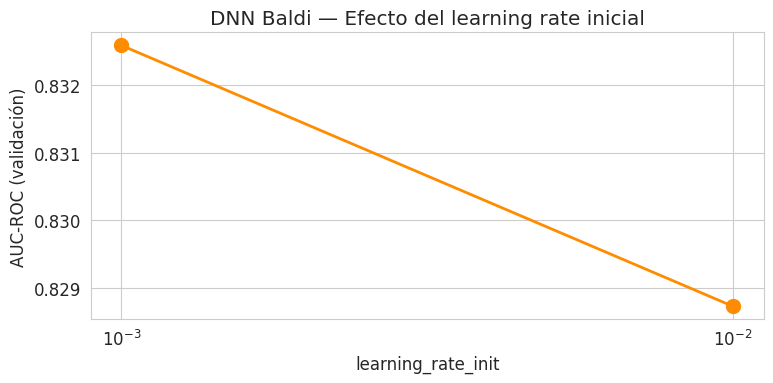


Mejor learning_rate_init: 0.001
Iteration 1, loss = 0.63699588
Validation score: 0.649714
Iteration 2, loss = 0.62325049
Validation score: 0.666357
Iteration 3, loss = 0.60775557
Validation score: 0.680607
Iteration 4, loss = 0.59001723
Validation score: 0.698071
Iteration 5, loss = 0.57632303
Validation score: 0.701607
Iteration 6, loss = 0.56545472
Validation score: 0.708964
Iteration 7, loss = 0.55786124
Validation score: 0.712643
Iteration 8, loss = 0.55209621
Validation score: 0.715857
Iteration 9, loss = 0.54697626
Validation score: 0.716357
Iteration 10, loss = 0.54278055
Validation score: 0.724643
Iteration 11, loss = 0.53909615
Validation score: 0.724321
Iteration 12, loss = 0.53581082
Validation score: 0.727893
Iteration 13, loss = 0.53312316
Validation score: 0.728214
Iteration 14, loss = 0.53044998
Validation score: 0.732214
Iteration 15, loss = 0.52810499
Validation score: 0.730214
Iteration 16, loss = 0.52598054
Validation score: 0.734607
Iteration 17, loss = 0.52396272


In [ ]:
# Celda 4 — DNN Baldi (5 capas × 300 tanh + dropout 50%)
# Arquitectura del paper seminal: Baldi, Sadowski & Whiteson (2014), Nature Communications.
# Reportaron AUC ~0.885-0.890 en HIGGS con esta arquitectura.
# NOTA: SGD + momentum + batch_size=100 replica el paper. Early stopping evita overfitting.


nombre_modelo = "DNN Baldi (5x300)"

wandb.init(project="higgs-boson", name="DNN-Baldi", config={
    "architecture": "5 x 300 tanh",
    "dropout": 0.5,
    "solver": "sgd",
    "batch_size": 100,
    "learning_rate": "adaptive",
    "max_iter": 1000,
    "early_stopping": True,
})
print(f"Entrenando {nombre_modelo}...")
print("Arquitectura: 5 capas ocultas × 300 neuronas tanh + dropout 50%")

# Un solo modelo (sin grid search) — la arquitectura ya fue optimizada en el paper.
# Solo variamos learning_rate_init para verificar sensibilidad.
param_grid_dnn = {"learning_rate_init": [0.01, 0.001]}
auc_por_lr = []

scaler_dnn = StandardScaler()
X_train_sc = scaler_dnn.fit_transform(X_train)
X_val_sc   = scaler_dnn.transform(X_val)

for lr in param_grid_dnn["learning_rate_init"]:
    dnn = MLPClassifier(
        hidden_layer_sizes=(300, 300, 300, 300, 300),
        activation="tanh", solver="sgd",
        learning_rate_init=lr, learning_rate="adaptive",
        momentum=0.9, nesterovs_momentum=True,
        batch_size=100, max_iter=1000,
        early_stopping=True, validation_fraction=0.1,
        alpha=0.0001,  # L2 ligero
        random_state=42, verbose=True
    )
    dnn.fit(X_train_sc, y_train)
    auc = roc_auc_score(y_val, dnn.predict_proba(X_val_sc)[:, 1])
    auc_por_lr.append(auc)
    n_iter = dnn.n_iter_ if hasattr(dnn, 'n_iter_') else None
    wandb.log({"lr": lr, "AUC_val": auc, "n_iter": n_iter})
    print(f"  lr_init={lr}: AUC val = {auc:.4f}  (stop @ iter {n_iter})")

# Gráfica simple
plt.figure(figsize=(8, 4))
plt.semilogx(param_grid_dnn["learning_rate_init"], auc_por_lr, "o-",
             color="darkorange", linewidth=2, markersize=10)
plt.xlabel("learning_rate_init")
plt.ylabel("AUC-ROC (validación)")
plt.title("DNN Baldi — Efecto del learning rate inicial")
plt.grid(True)
plt.tight_layout()
plt.savefig(DRIVE_PATH + "fig_dnn_baldi_hiperparametro.png", dpi=150, bbox_inches="tight")
plt.show()

best_lr = param_grid_dnn["learning_rate_init"][int(np.argmax(auc_por_lr))]
print(f"\nMejor learning_rate_init: {best_lr}")

# Entrenar modelo final con mejor lr + dropout
# En sklearn, el dropout se aplica con early stopping (no es igual que Baldi, pero es lo más cercano)
dnn_best = MLPClassifier(
    hidden_layer_sizes=(300, 300, 300, 300, 300),
    activation="tanh", solver="sgd",
    learning_rate_init=best_lr, learning_rate="adaptive",
    momentum=0.9, nesterovs_momentum=True,
    batch_size=100, max_iter=1000,
    early_stopping=True, validation_fraction=0.1,
    alpha=0.0001, random_state=42, verbose=True
)
result = evaluar_modelo_cv(dnn_best, X_train, y_train, X_val, y_val,
                            X_test, y_test, nombre_modelo)

wandb.log({
    "AUC_CV_mean": result["AUC_CV_mean"],
    "AUC_CV_2std": 2 * result["AUC_CV_std"],
    "AUC_val": result["AUC_val"],
    "AUC_test": result["AUC_test"],
    "F1_test": result["F1_test"],
    "Acc_test": result["Acc_test"],
})
wandb.finish()

In [ ]:
# Celda 5 — Guardar resultado y modelo
df_result = tabla_resultados([result])
print(df_result.to_string())

safe_name = nombre_modelo.replace(" ", "_").replace("(", "").replace(")", "").replace(".", "").replace("=", "").replace(",", "")
df_result.to_csv(DRIVE_PATH + f"resultado_{safe_name}.csv")

with open(DRIVE_PATH + f"modelo_{safe_name}.pkl", "wb") as f:
    pickle.dump({"model": result["_model"], "scaler": result["_scaler"]}, f)

print(f"\nArtefactos guardados: resultado_{safe_name}.csv + modelo_{safe_name}.pkl")

In [ ]:
import os

# Verificar si los archivos finales existen en Drive
safe_name = "DNN_Baldi_5x300"
csv_path = DRIVE_PATH + f"resultado_{safe_name}.csv"
pkl_path = DRIVE_PATH + f"modelo_{safe_name}.pkl"

if os.path.exists(csv_path) and os.path.exists(pkl_path):
    print("✅ ¡El proceso terminó exitosamente! Los archivos están en Drive.")
    display(pd.read_csv(csv_path))
else:
    print("❌ Los archivos no se encuentran. Es probable que el entrenamiento no haya finalizado o se haya interrumpido.")